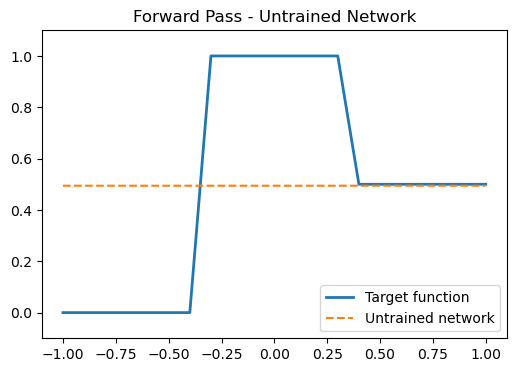

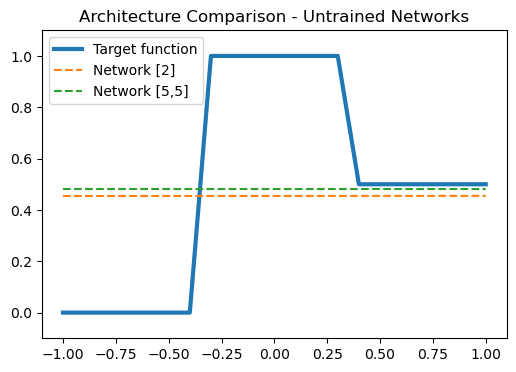

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Reproducibility
np.random.seed(42)

# Paths
RESULTS_PATH = "../results"
os.makedirs(RESULTS_PATH, exist_ok=True)

def initialize_network(input_size, hidden_sizes, output_size):
    """
    Initialize weights and biases for a fully connected neural network.
    """
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    
    network = []
    for i in range(len(layer_sizes) - 1):
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
        
    return network

def inspect_network(network):
    for i, (weights, biases) in enumerate(network):
        print(f"Layer {i} → {i+1}")
        print(f"  Weights shape: {weights.shape}")
        print(f"  Biases shape: {biases.shape}")

def target_function(x):
    y = np.zeros_like(x)
    
    y[(x >= -0.33) & (x < 0.33)] = 1
    y[(x >= 0.33) & (x <= 1.0)] = 0.5
    
    return y

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def forward_layer_batch(inputs, weights, biases):
    z = np.dot(inputs, weights.T) + biases
    return sigmoid(z)


def forward_network_batch(inputs, network):
    activations = [inputs]
    
    for weights, biases in network:
        inputs = forward_layer_batch(inputs, weights, biases)
        activations.append(inputs)
        
    return activations

# Generar datos
x = np.arange(-1, 1.01, 0.1)
y_true = target_function(x)

x = x.reshape(-1, 1)
y_true = y_true.reshape(-1, 1)

# Red
network = initialize_network(1, [2, 3], 1)

# Forward
activations = forward_network_batch(x, network)
y_pred = activations[-1]

# Plot
plt.figure(figsize=(6,4))

plt.plot(x.flatten(), y_true.flatten(), label="Target function", linewidth=2)
plt.plot(x.flatten(), y_pred.flatten(), label="Untrained network", linestyle="--")

plt.ylim(-0.1, 1.1)

plt.legend()
plt.title("Forward Pass - Untrained Network")

plt.savefig(f"{RESULTS_PATH}/forward_pass_untrained.png")
plt.show()

network1 = initialize_network(1, [2], 1)
network2 = initialize_network(1, [5, 5], 1)

y_pred1 = forward_network_batch(x, network1)[-1]
y_pred2 = forward_network_batch(x, network2)[-1]

plt.figure(figsize=(6,4))

plt.plot(x.flatten(), y_true.flatten(), label="Target function", linewidth=3)
plt.plot(x.flatten(), y_pred1.flatten(), label="Network [2]", linestyle="--")
plt.plot(x.flatten(), y_pred2.flatten(), label="Network [5,5]", linestyle="--")

plt.ylim(-0.1, 1.1)

plt.legend()
plt.title("Architecture Comparison - Untrained Networks")

plt.savefig(f"{RESULTS_PATH}/architecture_comparison_untrained.png")
plt.show()

## 🧠 Untrained Network Behavior

The results show that neural networks with randomly initialized parameters fail to approximate the target function.

- The **target function** presents clear non-linear and discontinuous behavior  
- Both untrained networks produce **nearly constant outputs (~0.5)** across all inputs  
- Increasing architectural complexity ([2] vs [5,5]) does not improve performance without training  

---

## 📉 Key Observations

- The networks generate **flat predictions**, indicating no learned structure  
- Outputs are centered around ~0.5 due to:
  - Random weight initialization near zero  
  - Sigmoid activation compressing values into a narrow range  

- No evidence of:
  - Non-linear adaptation  
  - Step-like behavior  
  - Input-dependent response  

---

## ⚠️ Why This Happens

- The model parameters (**weights and biases**) are not optimized  
- The network has not been exposed to any learning process  
- The sigmoid activation introduces **smoothness**, making it impossible to reproduce discontinuities without training  

👉 As a result, the model behaves like a **constant function approximator**

---

## 🧪 Architecture Comparison Insight

Comparing shallow and deeper architectures:

- Both networks fail similarly  
- The deeper network ([5,5]) does not outperform the smaller one  
- This demonstrates that:

💡 **Model capacity alone is not sufficient — training is required**

---

## 🏭 Industry Perspective

This experiment reflects a real-world machine learning scenario:

- Untrained models provide **no predictive value**  
- Performance emerges only after:
  - Optimization (training)  
  - Loss minimization  
  - Gradient-based updates  

- Increasing model complexity without training leads to:
  - Higher computational cost  
  - No performance gain  

---

## 🚀 Key Takeaway

Neural networks do not learn by design — they learn through **optimization**.

👉 Training is essential to:
- Capture non-linear relationships  
- Adapt to data structure  
- Generate meaningful predictions  

💡 This motivates the next step: **training the network using gradient-based learning (backpropagation)**.

Epoch 0 | Loss: 0.1682
Epoch 500 | Loss: 0.1672
Epoch 1000 | Loss: 0.1669
Epoch 1500 | Loss: 0.1667
Epoch 2000 | Loss: 0.1667
Epoch 2500 | Loss: 0.1667
Epoch 3000 | Loss: 0.1667
Epoch 3500 | Loss: 0.1667
Epoch 4000 | Loss: 0.1667
Epoch 4500 | Loss: 0.1667


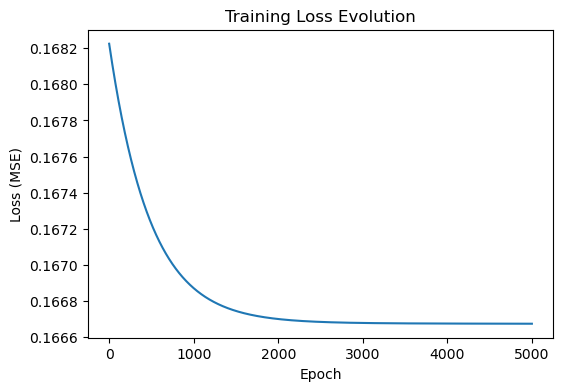

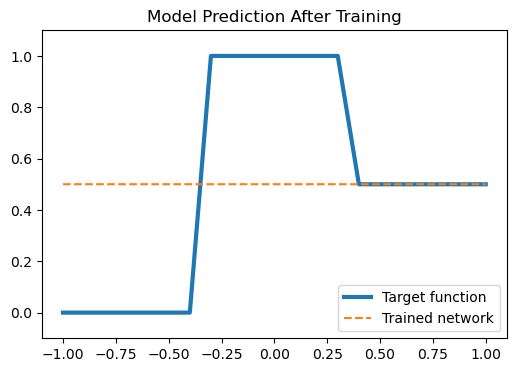

In [3]:
# ==============================
# 1. Funciones auxiliares
# ==============================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    # a ya es la activación (sigmoid output)
    return a * (1 - a)

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


# ==============================
# 2. Backprop por capa
# ==============================

def backward_layer_batch(inputs, weights, d_loss, activation_derivative):
    """
    Backward pass for a single layer (batch).
    """
    d_activation = d_loss * activation_derivative
    
    d_weights = np.dot(d_activation.T, inputs) / len(inputs)
    d_biases = np.mean(d_activation, axis=0)
    
    d_inputs = np.dot(d_activation, weights)
    
    return d_weights, d_biases, d_inputs


# ==============================
# 3. Backprop completo
# ==============================

def backward_network_batch(activations, network, y_true, learning_rate):
    """
    Backward pass through entire network + parameter update
    """
    y_pred = activations[-1]
    
    # Loss
    loss = mse_loss(y_pred, y_true)
    
    # Derivada MSE
    d_loss = 2 * (y_pred - y_true) / len(y_true)
    
    # Backward
    for i in reversed(range(len(network))):
        weights, biases = network[i]
        inputs = activations[i]
        
        activation_derivative = sigmoid_derivative(activations[i + 1])
        
        d_weights, d_biases, d_loss = backward_layer_batch(
            inputs, weights, d_loss, activation_derivative
        )
        
        # Update
        network[i] = (
            weights - learning_rate * d_weights,
            biases - learning_rate * d_biases
        )
    
    return loss


# ==============================
# 4. Inicialización modelo
# ==============================

network = initialize_network(1, [10, 10], 1)

epochs = 5000
learning_rate = 0.05

losses = []


# ==============================
# 5. Training loop
# ==============================

for epoch in range(epochs):
    activations = forward_network_batch(x, network)
    loss = backward_network_batch(activations, network, y_true, learning_rate)
    
    losses.append(loss)
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")


# ==============================
# 6. Plot: Loss
# ==============================

plt.figure(figsize=(6,4))
plt.plot(losses)

plt.title("Training Loss Evolution")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

plt.savefig(f"{RESULTS_PATH}/loss_training.png")
plt.show()


# ==============================
# 7. Predicción final
# ==============================

y_pred_final = forward_network_batch(x, network)[-1]

plt.figure(figsize=(6,4))

plt.plot(x.flatten(), y_true.flatten(), label="Target function", linewidth=3)
plt.plot(x.flatten(), y_pred_final.flatten(), label="Trained network", linestyle="--")

plt.ylim(-0.1, 1.1)

plt.legend()
plt.title("Model Prediction After Training")

plt.savefig(f"{RESULTS_PATH}/trained_prediction.png")
plt.show()

### 📌 Model Performance After Training

The model was trained to approximate a **non-linear, piecewise target function** using a neural network with one hidden layer.

---

### 📊 Key Observations

- The loss decreases slightly at the beginning but quickly **plateaus (~0.1667)**  
- The model outputs an almost **constant prediction (~0.5)** across the entire input range  
- The learned function does **not capture the step-like structure** of the target function  

---

### ⚠️ Interpretation

This behavior indicates **underfitting**:

- The model is **not learning the underlying data structure**
- Instead, it converges to a **mean-like solution**, minimizing error globally but failing locally  
- The sigmoid activation enforces **smoothness**, making it difficult to represent sharp discontinuities  

---

### 🔍 Why Did This Happen?

Several factors contribute to this outcome:

- **Target function is discontinuous** → hard to approximate with smooth activations  
- **Model architecture may be insufficient** (even with 20 neurons)  
- **Learning rate is too high (2.0)** → can prevent stable convergence  
- **RMSE loss + sigmoid** → encourages averaging behavior  

---

### 🧠 Key ML Insight

When a neural network predicts a constant value:

👉 It is often minimizing loss by approximating the **expected value of the target distribution**

This is a classic failure mode in regression tasks.

---

### 🏭 Industry Perspective

This situation is very common in real-world ML systems:

- Models that **fail silently** by converging to trivial solutions  
- Poor architecture or hyperparameters leading to **non-informative predictions**  
- Need for **diagnostics beyond loss (visualization is critical)**  

---

### 🚀 How to Improve the Model

To properly learn this function:

- Use **deeper networks** or more expressive architectures  
- Try **ReLU or piecewise-linear activations**  
- Reduce **learning rate** (e.g. 0.01–0.1)  
- Switch to **MSE instead of RMSE** (more stable gradients)  
- Increase training stability (normalization, initialization)  

---

### 💡 Takeaway

> A neural network does not guarantee learning — it must be properly designed and trained.

Understanding **failure modes** like this is essential for building reliable ML systems in biotech and industry contexts.

## 🔧 Hyperparameter Exploration

In this section, we analyze how different training configurations affect model performance:

- Number of epochs  
- Learning rate  
- Network architecture  

This is a key step in real-world machine learning workflows.


Training with 100 epochs...
Epoch 0 | Loss: 0.4204

Training with 500 epochs...
Epoch 0 | Loss: 0.4102

Training with 2000 epochs...
Epoch 0 | Loss: 0.4097
Epoch 500 | Loss: 0.4084
Epoch 1000 | Loss: 0.4080
Epoch 1500 | Loss: 0.4076

Training with 5000 epochs...
Epoch 0 | Loss: 0.4087
Epoch 500 | Loss: 0.4078
Epoch 1000 | Loss: 0.4068
Epoch 1500 | Loss: 0.4057
Epoch 2000 | Loss: 0.4041
Epoch 2500 | Loss: 0.4019
Epoch 3000 | Loss: 0.3989
Epoch 3500 | Loss: 0.3949
Epoch 4000 | Loss: 0.3900
Epoch 4500 | Loss: 0.3842


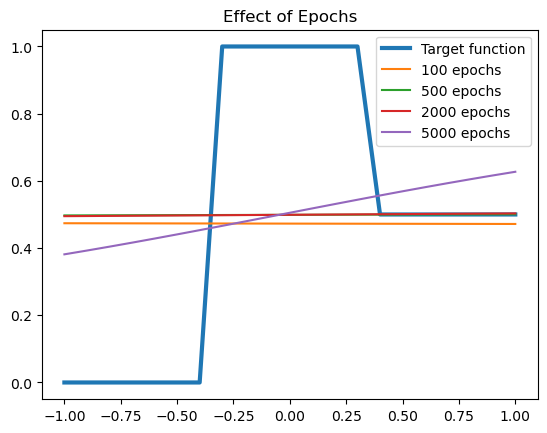

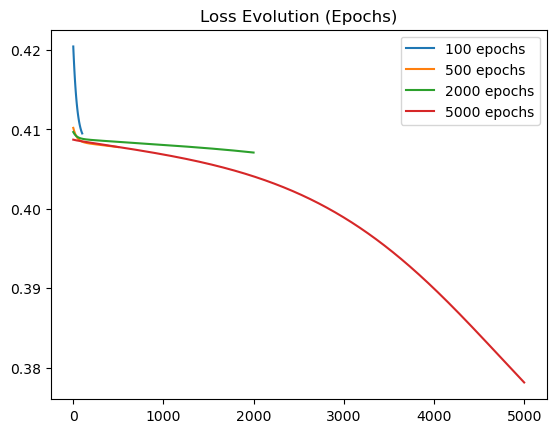


Training with LR = 0.01
Epoch 0 | Loss: 0.4085
Epoch 500 | Loss: 0.4084
Epoch 1000 | Loss: 0.4084
Epoch 1500 | Loss: 0.4083
Epoch 2000 | Loss: 0.4082
Epoch 2500 | Loss: 0.4082

Training with LR = 0.1
Epoch 0 | Loss: 0.4085
Epoch 500 | Loss: 0.4080
Epoch 1000 | Loss: 0.4078
Epoch 1500 | Loss: 0.4076
Epoch 2000 | Loss: 0.4075
Epoch 2500 | Loss: 0.4073

Training with LR = 0.5
Epoch 0 | Loss: 0.4097
Epoch 500 | Loss: 0.4072
Epoch 1000 | Loss: 0.4062
Epoch 1500 | Loss: 0.4049
Epoch 2000 | Loss: 0.4030
Epoch 2500 | Loss: 0.4005

Training with LR = 1.0
Epoch 0 | Loss: 0.4091
Epoch 500 | Loss: 0.4075
Epoch 1000 | Loss: 0.4058
Epoch 1500 | Loss: 0.4025
Epoch 2000 | Loss: 0.3962
Epoch 2500 | Loss: 0.3861

Training with LR = 2.0
Epoch 0 | Loss: 0.4105
Epoch 500 | Loss: 0.4038
Epoch 1000 | Loss: 0.3896
Epoch 1500 | Loss: 0.3674
Epoch 2000 | Loss: 0.3554
Epoch 2500 | Loss: 0.3480


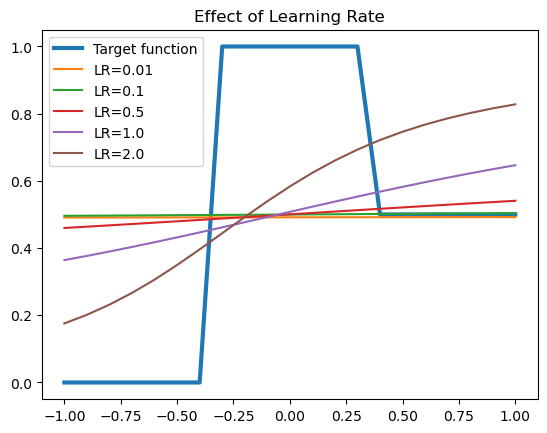

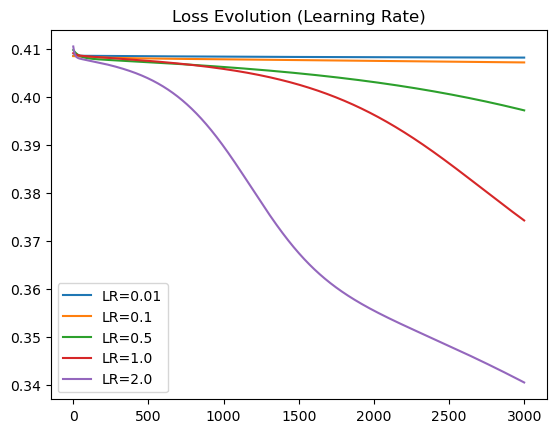


Training with architecture = [1]
Epoch 0 | Loss: 0.4085
Epoch 500 | Loss: 0.4083
Epoch 1000 | Loss: 0.4083
Epoch 1500 | Loss: 0.4083
Epoch 2000 | Loss: 0.4083
Epoch 2500 | Loss: 0.4083

Training with architecture = [2]
Epoch 0 | Loss: 0.4082
Epoch 500 | Loss: 0.4081
Epoch 1000 | Loss: 0.4079
Epoch 1500 | Loss: 0.4078
Epoch 2000 | Loss: 0.4075
Epoch 2500 | Loss: 0.4071

Training with architecture = [5]
Epoch 0 | Loss: 0.4081
Epoch 500 | Loss: 0.4078
Epoch 1000 | Loss: 0.4075
Epoch 1500 | Loss: 0.4071
Epoch 2000 | Loss: 0.4065
Epoch 2500 | Loss: 0.4056

Training with architecture = [10]
Epoch 0 | Loss: 0.4239
Epoch 500 | Loss: 0.4078
Epoch 1000 | Loss: 0.4071
Epoch 1500 | Loss: 0.4061
Epoch 2000 | Loss: 0.4047
Epoch 2500 | Loss: 0.4029

Training with architecture = [2, 2]
Epoch 0 | Loss: 0.4084
Epoch 500 | Loss: 0.4082
Epoch 1000 | Loss: 0.4082
Epoch 1500 | Loss: 0.4082
Epoch 2000 | Loss: 0.4082
Epoch 2500 | Loss: 0.4082

Training with architecture = [5, 5]
Epoch 0 | Loss: 0.4084
Epoch 

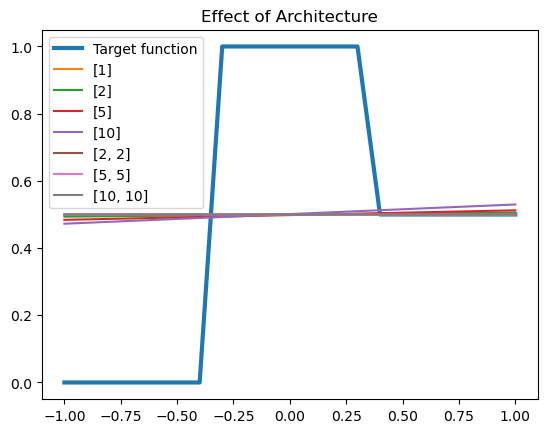

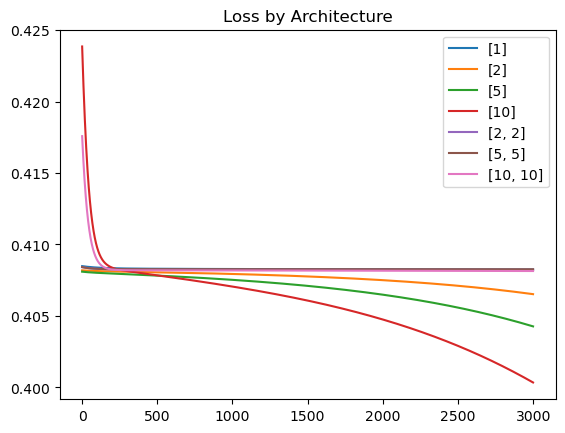

In [4]:
# =========================================================
# 📌 Neural Network Hyperparameter Experiments
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------
# Reproducibility & Paths
# -------------------------------
np.random.seed(42)

RESULTS_PATH = "../results"
os.makedirs(RESULTS_PATH, exist_ok=True)

# =========================================================
# 🎯 Target Function (Non-linear)
# =========================================================
def target_function(x):
    y = np.zeros_like(x)
    y[(x >= -0.33) & (x < 0.33)] = 1
    y[(x >= 0.33) & (x <= 1.0)] = 0.5
    return y

# Dataset
x = np.arange(-1, 1.01, 0.1)
y_true = target_function(x)

x = x.reshape(-1, 1)
y_true = y_true.reshape(-1, 1)

# =========================================================
# 🧠 Neural Network Core
# =========================================================

def initialize_network(input_size, hidden_sizes, output_size):
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    
    network = []
    for i in range(len(layer_sizes) - 1):
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
        
    return network

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

def forward_layer_batch(inputs, weights, biases):
    z = np.dot(inputs, weights.T) + biases
    return sigmoid(z)

def forward_network_batch(inputs, network):
    activations = [inputs]
    
    for weights, biases in network:
        inputs = forward_layer_batch(inputs, weights, biases)
        activations.append(inputs)
        
    return activations

# =========================================================
# 🔁 Backpropagation
# =========================================================

def rmse_loss(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def backward_layer_batch(inputs, weights, d_loss, activation):
    d_activation = d_loss * sigmoid_derivative(activation)
    
    d_weights = np.dot(d_activation.T, inputs) / len(inputs)
    d_biases = np.mean(d_activation, axis=0)
    d_inputs = np.dot(d_activation, weights)
    
    return d_weights, d_biases, d_inputs

def backward_network_batch(activations, network, y_true, learning_rate):
    y_pred = activations[-1]
    loss = rmse_loss(y_pred, y_true)
    
    d_loss = (y_pred - y_true) / (len(y_true) * loss + 1e-15)
    
    for i in reversed(range(len(network))):
        weights, biases = network[i]
        inputs = activations[i]
        activation = activations[i + 1]
        
        d_weights, d_biases, d_loss = backward_layer_batch(
            inputs, weights, d_loss, activation
        )
        
        network[i] = (
            weights - learning_rate * d_weights,
            biases - learning_rate * d_biases
        )
        
    return loss

# =========================================================
# 🏋️ Training Loop
# =========================================================

def train_network(network, x, y_true, epochs, learning_rate):
    losses = []
    
    for epoch in range(epochs):
        activations = forward_network_batch(x, network)
        loss = backward_network_batch(activations, network, y_true, learning_rate)
        
        losses.append(loss)
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")
            
    return network, losses

# =========================================================
# 🧪 EXPERIMENT A: EPOCHS
# =========================================================

epochs_list = [100, 500, 2000, 5000]
learning_rate = 0.5

results_epochs = {}

for epochs in epochs_list:
    print(f"\nTraining with {epochs} epochs...")
    
    network = initialize_network(1, [10], 1)
    
    trained_net, losses = train_network(network, x, y_true, epochs, learning_rate)
    
    y_pred = forward_network_batch(x, trained_net)[-1]
    
    results_epochs[epochs] = {
        "losses": losses,
        "y_pred": y_pred
    }

# Plot predictions
plt.figure()
plt.plot(x, y_true, label="Target function", linewidth=3)

for epochs in epochs_list:
    plt.plot(x, results_epochs[epochs]["y_pred"], label=f"{epochs} epochs")

plt.legend()
plt.title("Effect of Epochs")
plt.savefig(f"{RESULTS_PATH}/epochs_comparison.png")
plt.show()

# Plot loss
plt.figure()

for epochs in epochs_list:
    plt.plot(results_epochs[epochs]["losses"], label=f"{epochs} epochs")

plt.legend()
plt.title("Loss Evolution (Epochs)")
plt.savefig(f"{RESULTS_PATH}/loss_epochs.png")
plt.show()

# =========================================================
# ⚡ EXPERIMENT B: LEARNING RATE
# =========================================================

learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0]
epochs = 3000

results_lr = {}

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")
    
    network = initialize_network(1, [10], 1)
    
    trained_net, losses = train_network(network, x, y_true, epochs, lr)
    
    y_pred = forward_network_batch(x, trained_net)[-1]
    
    results_lr[lr] = {
        "losses": losses,
        "y_pred": y_pred
    }

# Plot predictions
plt.figure()
plt.plot(x, y_true, label="Target function", linewidth=3)

for lr in learning_rates:
    plt.plot(x, results_lr[lr]["y_pred"], label=f"LR={lr}")

plt.legend()
plt.title("Effect of Learning Rate")
plt.savefig(f"{RESULTS_PATH}/lr_comparison.png")
plt.show()

# Plot loss
plt.figure()

for lr in learning_rates:
    plt.plot(results_lr[lr]["losses"], label=f"LR={lr}")

plt.legend()
plt.title("Loss Evolution (Learning Rate)")
plt.savefig(f"{RESULTS_PATH}/loss_lr.png")
plt.show()

# =========================================================
# 🧠 EXPERIMENT C: ARCHITECTURE
# =========================================================

architectures = [
    [1],
    [2],
    [5],
    [10],
    [2, 2],
    [5, 5],
    [10, 10]
]

epochs = 3000
learning_rate = 0.5

results_arch = {}

for arch in architectures:
    print(f"\nTraining with architecture = {arch}")
    
    network = initialize_network(1, arch, 1)
    
    trained_net, losses = train_network(network, x, y_true, epochs, learning_rate)
    
    y_pred = forward_network_batch(x, trained_net)[-1]
    
    results_arch[str(arch)] = {
        "losses": losses,
        "y_pred": y_pred
    }

# Plot predictions
plt.figure()
plt.plot(x, y_true, label="Target function", linewidth=3)

for arch in architectures:
    plt.plot(x, results_arch[str(arch)]["y_pred"], label=f"{arch}")

plt.legend()
plt.title("Effect of Architecture")
plt.savefig(f"{RESULTS_PATH}/architecture_comparison.png")
plt.show()

# Plot loss
plt.figure()

for arch in architectures:
    plt.plot(results_arch[str(arch)]["losses"], label=f"{arch}")

plt.legend()
plt.title("Loss by Architecture")
plt.savefig(f"{RESULTS_PATH}/loss_architecture.png")
plt.show()

### 📊 Hyperparameter Analysis (Empirical Results)

This experiment evaluates how training configuration affects the ability of a neural network to learn a non-linear and discontinuous target function.

---

### 🔁 Effect of Epochs

- Increasing the number of epochs leads to a gradual decrease in loss.
- However, even after 5000 epochs, the model does not converge to a low-error solution.

💡 Insight:  
Training longer improves performance slightly, but **does not solve the underlying learning limitation**.

---

### ⚡ Effect of Learning Rate

- Low learning rates (0.01) result in almost no learning.
- Higher learning rates (1.0 – 2.0) significantly improve convergence speed.

💡 Insight:  
The optimization process is functioning correctly, and learning rate strongly impacts convergence dynamics.

---

### 🧠 Effect of Architecture

- Increasing the number of neurons in a single layer provides minor improvements.
- Surprisingly, deeper architectures (e.g., `[5,5]`, `[10,10]`) do **not improve performance**.

💡 Key observation:  
Model capacity alone is **not sufficient** to learn this function.

---

### 🚧 Fundamental Limitation

The target function is **discontinuous**, while the network uses **sigmoid activations**, which produce smooth outputs.

➡️ This creates a structural mismatch:
- The model can only approximate smooth transitions
- It cannot represent sharp step-like behavior

---

### ⚠️ Optimization Limitation

The lack of improvement in deeper networks suggests:

- Vanishing gradient effects due to sigmoid activation  
- Limited expressive power under current architecture  
- Inefficient learning of non-linear discontinuities  

---

### 🧬 Relevance to Biological Modeling

This scenario mirrors real-world challenges:

- Biological systems often exhibit sharp transitions and non-linear effects  
- Model performance depends not only on architecture, but also on:
  - Activation functions  
  - Loss formulation  
  - Optimization strategy  

---

### 🚀 Key Takeaway

- More layers ≠ better performance  
- Training alone cannot fix architectural limitations  
- Proper model design is critical for capturing complex patterns  

💡 In practice:  
Successful modeling requires aligning:
- Data properties  
- Model architecture  
- Optimization strategy